In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('hotel_bookings.csv')
df.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2015,2015,2015,2015,2015
arrival_date_month,July,July,July,July,July
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2
adults,2,2,1,1,2


In [3]:
# Data preprocessing:-
# 1st col (hotel) - type obj no missing values -> OneHot
# 2nd col (is_canceled) - Target
# 3rd col (lead_time) - int values no missing values -> Std Scalar
# 4th col (arrival_date_year) - type int no missing vlaues -> Drop
# 5th col (arrival_date_month) - type obj no missing vlaues -> OneHot
# 6th col (arrival_date_week_number) - type int no missing values -> Std Scalar
# 7th col (arrival_date_day_of_month) - type int no missig values -> Std Scalar
# 8th col (stays_in_weekend_nights) - type int no missing values -> Std Scalar
# 9th col (stays_in_week_nights) - type int no missing values -> Std Scalar
# 10th col (adults) - type int no missing values -> Std Scalar
# 11th col (children) - type int -> 4 missing values -> Std Scalar
# 12th col (babies) - type int no missing values -> Std Scalar
# 13th col (meal) - type obj -> has 1196 obj's as undefined -> OneHot
# 14th col (country) - type obj no missing vlaues -> OneHot
# 15th col (market_segment) - type obj -> has 2 obj's as undefined -> OneHot
# 16th col (distribution_channel) - type obj -> has 5 obj's as undefined -> OneHot
# 17th col (is_repeated_guest) - type int no missing values -> 
# 18th col (previous_cancellations) - type int no missing values -> Std Scalar
# 19th col (previous_bookings_not_canceled) - type int no missing values -> Std Scalar
# 20th col (reserved_room_type) - type obj no missing vlaues -> Ordinal
# 21th col (assigned_room_type) - type obj no missing vlaues -> Ordinal
# 22st col (booking_changes) - type int no missing values -> Std Scalar
# 23nd col (deposit_type) - type obj no missing vlaues -> Ordinal
# 24rd col (agent) - type int -> 16340 missing values -> Std Scalar
# 25th col (company) - type int -> 112593 missing values -> Drop
# 26th col (days_in_waiting_list) -> type int no missing values -> Std Scalar
# 27th col (customer_type) -> type obj no missing vlaues -> OneHot
# 28th col (adr) -> type int needs to fix negative values -> Std Scalar
# 29th col (required_car_parking_spaces) -> type int no missing vlaues -> Std Scaler
# 30th col (total_of_special_requests) -> type int no missing vlaues -> Std Scaler
# 31st col (reservation_status) -> type obj no missing vlaues -> Drop
# 32nd col (reservation_status_date) -> type int no missing vlaues -> Drop

In [4]:
for i in df.columns:
    print(f"{i} = {df[i].unique()}")

hotel = ['Resort Hotel' 'City Hotel']
is_canceled = [0 1]
lead_time = [342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 361 207 174 330 134 350 334 283 153 197 133 241 193 2

In [5]:
df.shape

(119390, 32)

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# Dropped useless cols
df = df.drop(columns=['reservation_status_date', 'reservation_status', 'company', 'arrival_date_year','agent'])

In [8]:
# Replace undefined strings with nan

df['meal'] = df['meal'].replace('Undefined', np.nan)
df['market_segment'] = df['market_segment'].replace('Undefined', np.nan)
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', np.nan)

In [9]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

<Axes: xlabel='is_canceled', ylabel='count'>

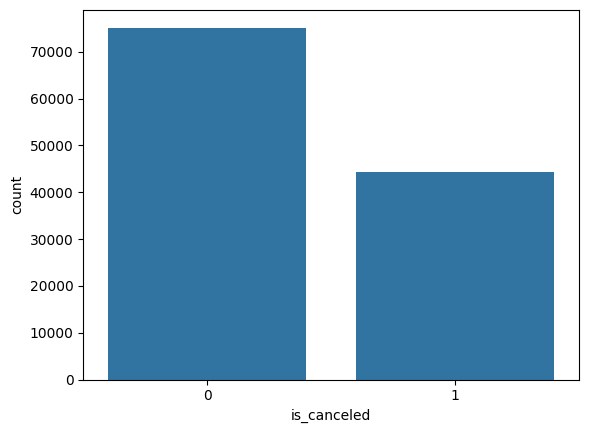

In [10]:
import seaborn as sns

# Checking if the data is balanced
sns.countplot(x='is_canceled', data=df)

<Axes: xlabel='lead_time', ylabel='Density'>

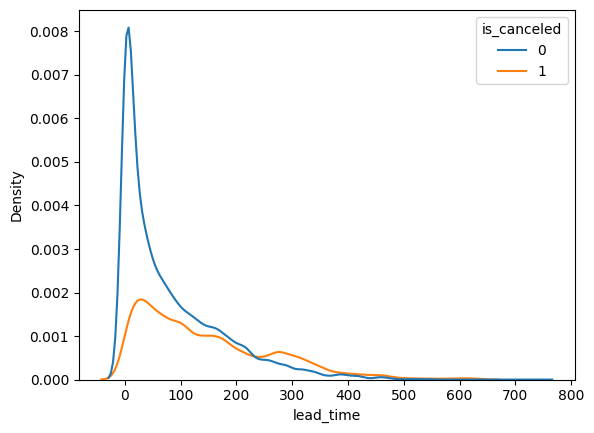

In [11]:
sns.kdeplot(x='lead_time', hue='is_canceled', data=df)

<Axes: xlabel='deposit_type', ylabel='count'>

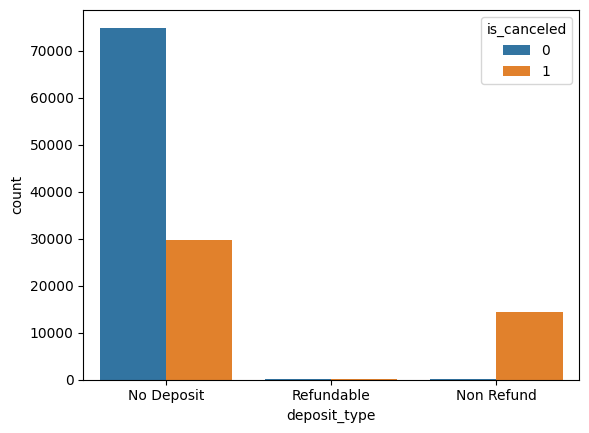

In [12]:
sns.countplot(x='deposit_type', hue='is_canceled', data=df)

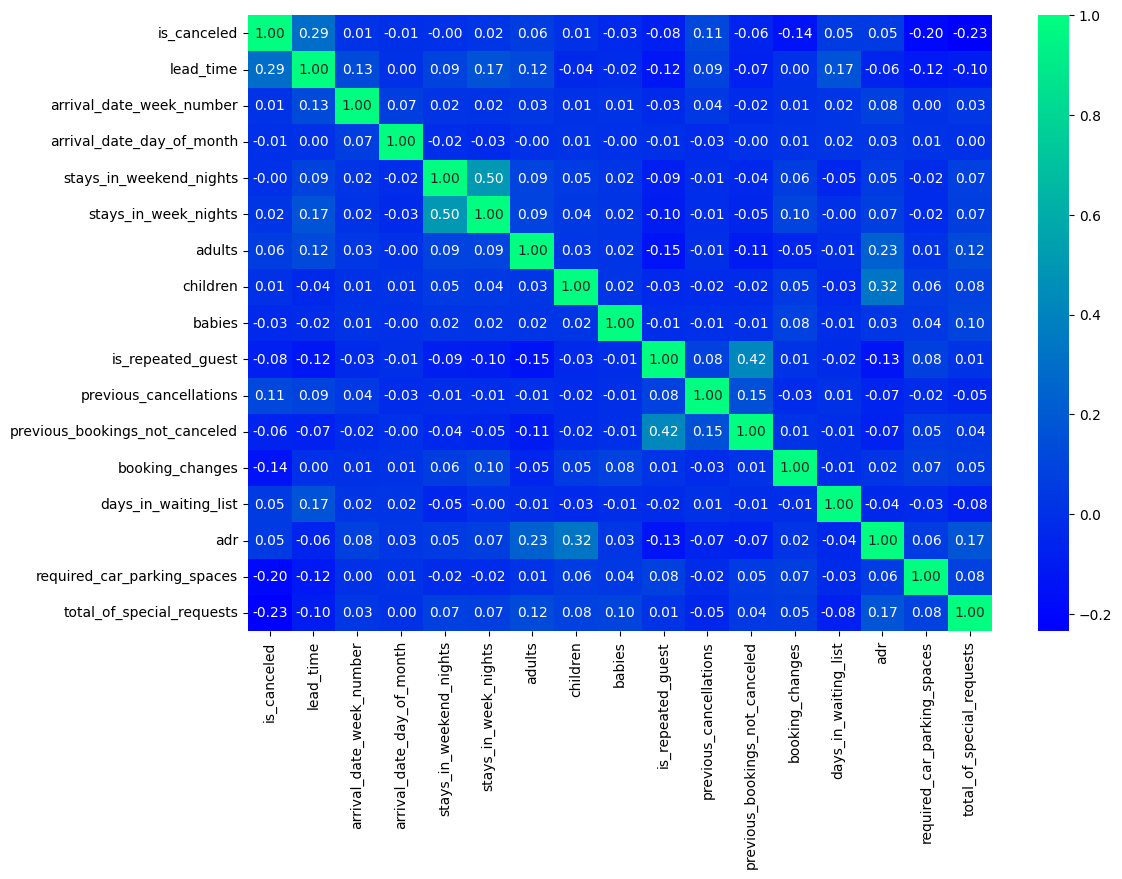

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='winter', fmt='.2f')
plt.show()

<Axes: ylabel='adr'>

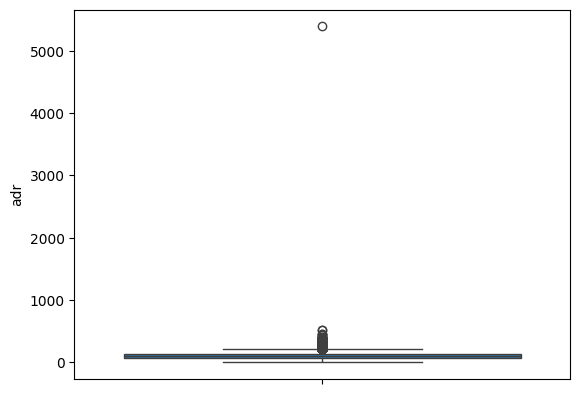

In [14]:
sns.boxplot(df['adr'])

In [15]:
df['adr'] = np.where(df['adr'] > 900, df['adr'].median(), df['adr'])
df['adr'] = np.where(df['adr'] < 0, df['adr'].median(), df['adr'])

<Axes: ylabel='adr'>

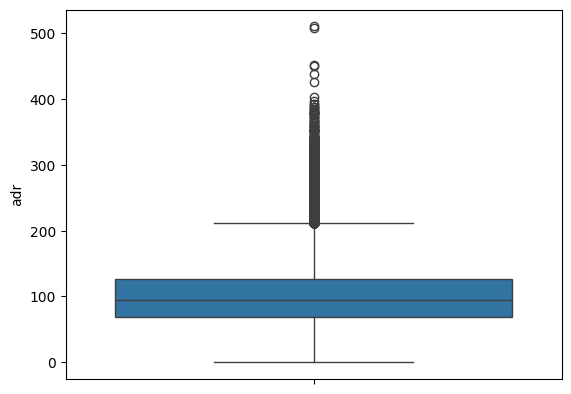

In [16]:
sns.boxplot(df['adr'])

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline

In [18]:
num_cols = ['lead_time','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights',
           'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled',
           'booking_changes','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']

ohe_cols = ['hotel','arrival_date_month','meal','country','market_segment','distribution_channel','customer_type']
ord_cols = ['reserved_room_type','assigned_room_type','deposit_type']
order = [['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P'],
         ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P'],
         ['Non Refund','Refundable','No Deposit']
        ]

In [19]:
num_pipe = Pipeline( steps = [
    ('impute', SimpleImputer()),
    ('scale', StandardScaler())
])

ohe_pipe = Pipeline( steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output = False,handle_unknown='ignore'))
])

ord_pipe = Pipeline( steps = [
    ('ord', OrdinalEncoder(categories=order))
])

In [20]:
transformer = ColumnTransformer( transformers= [
    ('Numerical', num_pipe, num_cols),
    ('OneHot', ohe_pipe, ohe_cols),
    ('Ordinal', ord_pipe, ord_cols)
], remainder='passthrough')

In [21]:
final = Pipeline( steps = [
    ('trf', transformer),
    ('model', XGBClassifier(learning_rate = 0.2, max_depth = 8, n_estimators = 300))
])

In [22]:
x = df.drop(columns='is_canceled')
y = df.iloc[:,1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [23]:
final.fit(x_train, y_train)

,steps,"[('trf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical', ...), ('OneHot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred = final.predict(x_test)

In [25]:
accuracy_score(y_test, y_pred)

0.880280313817461

In [26]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [4, 6, 8]
}

grid = GridSearchCV(final, param_grid, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [4, 6, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Numerical', ...), ('OneHot', ...), ...]"


In [27]:
print(f"Best Parameters := {grid.best_params_}")
print(f"Best Score := {grid.best_score_}")

Best Parameters := {'model__learning_rate': 0.2, 'model__max_depth': 8, 'model__n_estimators': 300}
Best Score := 0.8788843026516627


In [28]:
import joblib
joblib.dump(final, 'hotel_cancellation_model.pkl')

['hotel_cancellation_model.pkl']

In [ ]:
import gradio as gr

model = joblib.load('hotel_cancellation_model.pkl')
template_row = x_train.iloc[[22]].copy()

def predict(lead_time, stays_week, requests, parking, adr, repeated, deposit, segment, hotel, meal):
    current_booking = template_row.copy()

    current_booking['lead_time'] = lead_time
    current_booking['stays_in_week_nights'] = stays_week
    current_booking['total_of_special_requests'] = requests
    current_booking['required_car_parking_spaces'] = parking
    current_booking['adr'] = adr
    current_booking['is_repeated_guest'] = repeated
    current_booking['deposit_type'] = deposit
    current_booking['market_segment'] = segment
    current_booking['hotel'] = hotel
    current_booking['meal'] = meal

    prediction = model.predict(current_booking)[0]
    prob = model.predict_proba(current_booking)[0][1]
    if prediction == 1:
        return f"🚨 HIGH RISK ({prob:.1%}) - Likely to Cancel"
    else:
        return f"✅ LOW RISK ({prob:.1%}) - Likely to Stay"

demo = gr.Interface(
    fn = predict,
    inputs = [
        gr.Slider(0, 400, label="Leading days"),
        gr.Number(label='Stay in week nights'),
        gr.Slider(0, 8, step = 1, label='Special requests'),
        gr.Slider(0, 5, step = 1, label='Number of parking spaces needed'),
        gr.Number(label='ADR (Price per night)'),
        gr.Radio([0,1], label='Repeated Guest?'),
        gr.Dropdown(['No Deposit', 'Non Refund', 'Refundable'], label="Deposit Type"),
        gr.Dropdown(['Online TA', 'Offline TA', 'Direct', 'Corporate', 'Groups'], label="Market Segment"),
        gr.Dropdown(['City Hotel', 'Resort Hotel'], label="Hotel Type"),
        gr.Dropdown(['BB', 'HB', 'FB', 'SC'], label="Meal Plan")
    ],
    outputs = "text",
    title="Hotel booking cancellation predictor"
)
demo.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [34]:
df[df['is_canceled'] == 1].T

,8,9,10,27,32,34,35,38,40,45,...,107980,107997,108000,108459,108829,110280,111355,111924,111925,117295
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,...,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
lead_time,85,75,23,60,96,45,40,43,45,47,...,16,13,13,31,25,132,4,7,6,0
arrival_date_month,July,July,July,July,July,July,July,July,July,July,...,April,May,May,July,May,April,June,May,July,August
arrival_date_week_number,27,27,27,27,27,27,27,27,27,27,...,15,22,22,29,18,17,23,22,29,31
arrival_date_day_of_month,1,1,1,1,1,2,2,2,2,2,...,12,29,29,16,6,25,5,31,17,2
stays_in_weekend_nights,0,0,0,2,2,1,1,1,2,2,...,0,1,1,2,2,0,1,0,1,0
stays_in_week_nights,3,3,4,5,8,3,3,3,3,5,...,1,2,2,0,1,0,0,1,0,2
adults,2,2,2,2,2,3,3,3,2,2,...,1,1,1,1,1,0,1,1,1,1
children,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
